# From picks to a catalog with GaMMA

Notebook 05 produced a pile of picks: a phase name, a time, and the station
it came from. A pile of picks is not a catalog. Turning one into the other
means deciding **which picks belong to the same earthquake**, and then where
and when that earthquake was — association and location, in one step.

[GaMMA](https://github.com/AI4EPS/GaMMA) does that by treating the picks as a
Gaussian mixture in which each component is an earthquake, and the travel
time from a hypocentre is the mean. It is a good fit for DAS precisely
because it does not care how many "stations" there are.

```{note}
The install is `pip install git+https://github.com/AI4EPS/GaMMA.git`, and
mind the name: the distribution is called `gmma` but you `import gamma`. The
package on PyPI called `GaMMA` is something else entirely.
```

In [1]:
import numpy as np
import pandas as pd
import pyproj
from obspy import read_inventory

import xdas as xd
from gamma.utils import association

## The two tables GaMMA wants

A **stations** table, positioned in a local Cartesian frame in kilometres,
and a **picks** table keyed by the same station ids.

In [2]:
picks = pd.read_csv("outputs/station_picks.csv", parse_dates=["time"])
inventory = read_inventory("data/stations/stations.xml")

rows = [
    (f"{net.code}.{sta.code}", sta.latitude, sta.longitude, sta.elevation)
    for net in inventory
    for sta in net
]
stations = pd.DataFrame(
    rows, columns=["id", "latitude", "longitude", "elevation"]
).drop_duplicates("id")

An azimuthal-equidistant projection centred on the network turns degrees
into kilometres, which is what the travel-time calculation needs:

In [3]:
proj = pyproj.Proj(
    proj="aeqd",
    lat_0=stations["latitude"].mean(),
    lon_0=stations["longitude"].mean(),
    units="km",
)
stations["x(km)"], stations["y(km)"] = proj(
    stations["longitude"].values, stations["latitude"].values
)
stations["z(km)"] = -stations["elevation"] / 1000.0
stations = stations[stations["id"].isin(set("C1." + picks["station"]))]
stations

,id,latitude,longitude,elevation,x(km),y(km),z(km)
9,C1.CO01,-29.97730,-70.09390,2157.0,98.807396,89.672232,-2.157
10,C1.CO02,-31.20370,-71.00030,1190.0,11.188702,-45.847080,-1.190
11,C1.CO03,-30.83890,-70.68910,1003.0,41.001996,-5.474415,-1.003
12,C1.CO04,-32.04330,-70.97470,2401.0,13.507541,-138.944982,-2.401
13,C1.CO05,-29.91864,-71.23841,101.0,-11.656478,96.616871,-0.101
18,C1.VA06,-32.56117,-71.29765,80.0,-16.902025,-196.377769,-0.080


The picks table needs four columns under GaMMA's own names — the station
`id`, the `timestamp`, the phase `type` in lower case, and the model's
confidence as `prob`:

In [4]:
gamma_picks = pd.DataFrame(
    {
        "id": picks["network"] + "." + picks["station"],
        "timestamp": picks["time"],
        "type": picks["phase"].str.lower(),
        "prob": picks["value"],
    }
)
gamma_picks

,id,timestamp,type,prob
0,C1.CO01,2023-11-03 12:27:14.100000,p,0.698469
1,C1.CO01,2023-11-03 12:27:30.820000,s,0.780952
2,C1.CO02,2023-11-03 12:27:14.500000,p,0.715876
3,C1.CO02,2023-11-03 12:27:33.460000,s,0.420162
4,C1.CO03,2023-11-03 12:27:11.700000,p,0.911087
5,C1.CO03,2023-11-03 12:27:27.840000,s,0.536183
6,C1.CO04,2023-11-03 12:27:27.129998,p,0.482439
7,C1.CO04,2023-11-03 12:27:53.549998,s,0.363163
8,C1.CO05,2023-11-03 12:26:57.420000,p,0.967788
9,C1.CO05,2023-11-03 12:27:03.020000,s,0.860738


## Configuring the association

The search volume, a velocity model (two constants here — a real study would
pass an eikonal solver), and the thresholds that decide when a cluster of
picks is convincing enough to be called an earthquake:

In [5]:
xlim = (stations["x(km)"].min() - 50, stations["x(km)"].max() + 50)
ylim = (stations["y(km)"].min() - 50, stations["y(km)"].max() + 50)
zlim = (0.0, 60.0)

config = {
    "dims": ["x(km)", "y(km)", "z(km)"],
    "x(km)": xlim,
    "y(km)": ylim,
    "z(km)": zlim,
    "bfgs_bounds": (xlim, ylim, zlim, (None, None)),
    "use_dbscan": True,
    "dbscan_eps": 25.0,
    "dbscan_min_samples": 3,
    "use_amplitude": False,  # we did not measure amplitudes, so no magnitudes
    "vel": {"p": 6.0, "s": 6.0 / 1.75},
    "method": "BGMM",
    "oversample_factor": 4,
    "min_picks_per_eq": 8,
    "max_sigma11": 2.0,
    "max_sigma22": 1.0,
    "max_sigma12": 1.0,
    "ncpu": 1,
}

In [6]:
events, assignments = association(gamma_picks, stations, config, method="BGMM")
print(f"{len(events)} event(s) from {len(gamma_picks)} picks")

Clustering (eps=20.83):   0%|          | 0/2 [00:00<?, ?it/s]

Clustering (eps=20.83): 100%|██████████| 2/2 [00:00<00:00, 25343.23it/s]

Associating 12 picks with 1 CPUs
.1 event(s) from 12 picks



/home/trabatto/pkgs/tutorials/.venv/lib/python3.12/site-packages/gamma/seismic_ops.py:302: OptimizeWarning: Unknown solver options: iprint
  opt = scipy.optimize.minimize(


## The catalog

In [7]:
catalog = pd.DataFrame(events)
catalog["longitude"], catalog["latitude"] = proj(
    catalog["x(km)"].values, catalog["y(km)"].values, inverse=True
)
catalog = catalog.rename(columns={"z(km)": "depth(km)"})
catalog[
    ["time", "latitude", "longitude", "depth(km)", "num_picks", "gamma_score", "sigma_time"]
]

,time,latitude,longitude,depth(km),num_picks,gamma_score,sigma_time
0,2023-11-03T12:26:49.753,-29.97883,-71.515395,36.333819,8,9.0,0.328133


In [8]:
catalog.to_csv("outputs/catalog.csv", index=False)

One earthquake, with an origin time, a hypocentre and a residual — built
from nothing but waveforms and a pretrained model. Worth noting that the
USGS and EMSC catalogs both have **nothing** at this time and place: at this
magnitude, in this region, we are not rediscovering a known event.

Drawn on a map, with the stations that contributed:

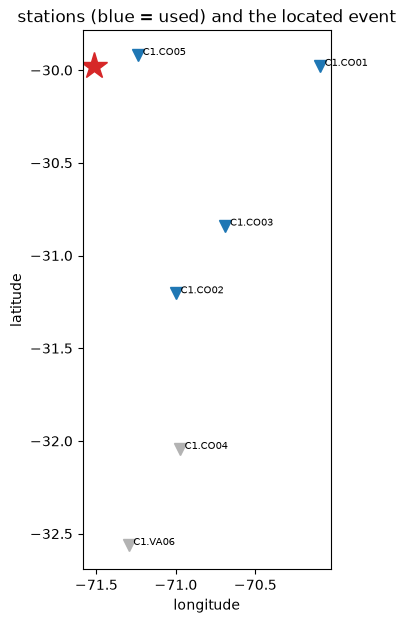

In [9]:
import matplotlib.pyplot as plt

assigned = pd.DataFrame(assignments, columns=["pick_index", "event_index", "prob"])
used = set(gamma_picks.loc[assigned["pick_index"], "id"])

fig, ax = plt.subplots(figsize=(7, 7))
for _, station in stations.iterrows():
    contributed = station["id"] in used
    ax.plot(
        station["longitude"],
        station["latitude"],
        "v",
        ms=9,
        c="C0" if contributed else "0.7",
    )
    ax.text(station["longitude"] + 0.03, station["latitude"], station["id"], fontsize=7)
ax.plot(catalog["longitude"], catalog["latitude"], "*", ms=20, c="C3")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("stations (blue = used) and the located event")
ax.set_aspect(1 / np.cos(np.deg2rad(31)))
plt.show()

## Checking it arrival by arrival

A location is a hypothesis. The honest test is to predict every arrival from
it and look at the residuals:

In [10]:
from obspy.geodetics import gps2dist_azimuth

event = catalog.iloc[0]
origin = pd.Timestamp(event["time"])
velocity = {"P": config["vel"]["p"], "S": config["vel"]["s"]}

check = gamma_picks.copy()
check["phase"] = picks["phase"].values
coords = stations.set_index("id")
distances = []
for _, row in check.iterrows():
    station = coords.loc[row["id"]]
    metres, _, _ = gps2dist_azimuth(
        event["latitude"], event["longitude"], station["latitude"], station["longitude"]
    )
    distances.append(np.hypot(metres / 1000.0, event["depth(km)"]))
check["hypo(km)"] = distances
check["predicted"] = [
    origin + pd.Timedelta(seconds=d / velocity[p])
    for d, p in zip(check["hypo(km)"], check["phase"])
]
check["residual(s)"] = (check["timestamp"] - check["predicted"]).dt.total_seconds()
check.sort_values("hypo(km)")[["id", "phase", "hypo(km)", "residual(s)"]]

,id,phase,hypo(km),residual(s)
9,C1.CO05,S,45.603059,-0.033892
8,C1.CO05,P,45.603059,0.066490
5,C1.CO03,S,129.285799,0.378642
4,C1.CO03,P,129.285799,0.399367
0,C1.CO01,P,141.914216,0.694631
1,C1.CO01,S,141.914216,-0.324646
3,C1.CO02,S,148.996765,0.249610
2,C1.CO02,P,148.996765,-0.085794
7,C1.CO04,S,237.433790,-5.454524
6,C1.CO04,P,237.433790,-2.195300


Most residuals are a few tenths of a second, which is as much as two
constant velocities can be expected to deliver. Two of them are enormous —
tens of seconds — and those are the `VA06` picks: at 287 km, that station
recorded nothing, and the picker labelled noise. GaMMA left them out, which
is exactly what an associator is for.

The far station drifts too, by a few seconds at 235 km, for the same reason:
a single P velocity cannot describe a path that samples the whole crust.

## What the cable adds

The DAS never entered the association, so it is an independent check.
S−P at a channel gives a hypocentral distance without knowing anything about
where the event is:

In [11]:
das = pd.read_csv("outputs/picks.csv", parse_dates=["time"])
first_p = das[das["phase"] == "P"].groupby("distance")["time"].min()
first_s = das[das["phase"] == "S"].groupby("distance")["time"].min()
both = first_p.index.intersection(first_s.index)
sp = (first_s[both] - first_p[both]).dt.total_seconds()

# the median, because a few channels have spurious picks
slowness = 1 / velocity["S"] - 1 / velocity["P"]
print(f"channels with both phases : {len(both)}")
print(f"median S-P                : {sp.median():.2f} s")
print(f"implied hypocentral range : {sp.median() / slowness:.0f} km")
print(f"catalog depth             : {event['depth(km)']:.0f} km")
print(f"first DAS P               : {first_p.min()}")
print(f"  i.e. {(first_p.min() - origin).total_seconds():.2f} s after the origin time")

channels with both phases : 163
median S-P                : 4.52 s
implied hypocentral range : 36 km
catalog depth             : 36 km
first DAS P               : 2023-11-03 12:20:13.720000
  i.e. -396.03 s after the origin time


Those two numbers are measuring nearly the same thing. The cable sits almost
above the source, so its distance to the hypocentre *is* essentially the
depth — and an independent S−P measurement on the fiber agrees with the
network's depth to within a few kilometres. For an eight-pick location and a
velocity model of two constants, that is about as well as it can be expected
to do.

## Putting the fiber into the association

The cable is currently only a witness. Making it a participant means adding
its channels to the association as stations — GaMMA has no notion of "DAS",
a channel is a point that recorded a phase at a time.

That needs one thing: where each channel physically is. It already
travelled here, attached during consolidation (notebook 01) from the real
cable geometry — pull it off `outputs/singlecable.nc` and match it to
whichever channels the picker actually fired on:

In [12]:
cable = xd.open("outputs/singlecable.nc")

channels = np.sort(das["distance"].unique())
latitude = np.interp(
    channels, cable["distance"].values, cable["latitude"].values, left=np.nan, right=np.nan
)
longitude = np.interp(
    channels, cable["distance"].values, cable["longitude"].values, left=np.nan, right=np.nan
)

das_stations = pd.DataFrame(
    {"id": [f"DAS.{d:.0f}" for d in channels], "latitude": latitude, "longitude": longitude, "elevation": 0.0}
).dropna(subset=["latitude", "longitude"])
das_stations["x(km)"], das_stations["y(km)"] = proj(
    das_stations["longitude"].values, das_stations["latitude"].values
)
das_stations["z(km)"] = 0.0  # the fiber sits at the surface

print(f"{len(das_stations)} of {len(channels)} picked channels fall on the surveyed 102 km of cable")

174 of 202 picked channels fall on the surveyed 102 km of cable


Stack them onto the two tables from before and associate again:

In [13]:
das_gamma_picks = pd.DataFrame(
    {
        "id": das["distance"].map(lambda d: f"DAS.{d:.0f}"),
        "timestamp": das["time"],
        "type": das["phase"].str.lower(),
        "prob": das["value"],
    }
)
das_gamma_picks = das_gamma_picks[das_gamma_picks["id"].isin(das_stations["id"])]

combined_stations = pd.concat([stations, das_stations], ignore_index=True)
combined_picks = pd.concat([gamma_picks, das_gamma_picks], ignore_index=True)

das_xlim = (combined_stations["x(km)"].min() - 50, combined_stations["x(km)"].max() + 50)
das_ylim = (combined_stations["y(km)"].min() - 50, combined_stations["y(km)"].max() + 50)
das_config = config | {
    "x(km)": das_xlim,
    "y(km)": das_ylim,
    "bfgs_bounds": (das_xlim, das_ylim, zlim, (None, None)),
}

das_events, das_assignments = association(combined_picks, combined_stations, das_config, method="BGMM")
print(
    f"{len(das_events)} event(s) from {len(combined_picks)} picks "
    f"({len(stations)} stations + {len(das_stations)} DAS channels)"
)

Clustering (eps=20.83):   0%|          | 0/3 [00:00<?, ?it/s]

Clustering (eps=20.83): 100%|██████████| 3/3 [00:00<00:00, 33825.03it/s]

Associating 375 picks with 1 CPUs
.


/home/trabatto/pkgs/tutorials/.venv/lib/python3.12/site-packages/gamma/seismic_ops.py:302: OptimizeWarning: Unknown solver options: iprint
  opt = scipy.optimize.minimize(


.3 event(s) from 375 picks (6 stations + 174 DAS channels)


/home/trabatto/pkgs/tutorials/.venv/lib/python3.12/site-packages/gamma/seismic_ops.py:302: OptimizeWarning: Unknown solver options: iprint
  opt = scipy.optimize.minimize(


More than one event, most likely — a few hundred noisy per-channel picks
give DBSCAN plenty of chances to seed a cluster that is not an earthquake.
The tell is `min_picks_per_eq`: a real cluster clears it comfortably, a
spurious one sits right at the floor. Sorting by `gamma_score` finds the
real one without having to look at a map:

In [14]:
das_catalog = pd.DataFrame(das_events)
das_catalog["longitude"], das_catalog["latitude"] = proj(
    das_catalog["x(km)"].values, das_catalog["y(km)"].values, inverse=True
)
das_catalog = das_catalog.rename(columns={"z(km)": "depth(km)"}).sort_values(
    "gamma_score", ascending=False
)
das_catalog[
    ["time", "latitude", "longitude", "depth(km)", "num_picks", "gamma_score", "sigma_time"]
]

,time,latitude,longitude,depth(km),num_picks,gamma_score,sigma_time
0,2023-11-03T12:26:49.909,-29.814670,-71.624741,28.440011,326,321.030925,0.384495
1,2023-11-03T12:26:48.183,-29.930134,-71.578749,35.613936,8,12.690084,0.764529
2,2023-11-03T12:29:01.510,-29.521960,-71.362957,0.000000,13,12.593140,0.569170


In [15]:
best = das_catalog.iloc[0]
print(f"network alone     : {event['num_picks']:.0f} picks, depth {event['depth(km)']:.0f} km, score {event['gamma_score']:.1f}")
print(f"network + DAS     : {best['num_picks']:.0f} picks, depth {best['depth(km)']:.0f} km, score {best['gamma_score']:.1f}")
print(f"origin time shift : {(pd.Timestamp(best['time']) - origin).total_seconds():+.2f} s")

network alone     : 8 picks, depth 36 km, score 9.0
network + DAS     : 326 picks, depth 28 km, score 321.0
origin time shift : +0.16 s


Dozens of times more picks constrain the same origin, from an associator
that was never told the DAS event and the network event were the same
thing — only that a coordinate came with every pick. The depth moves, which
is not a contradiction: an eight-pick, two-velocity fit was never going to
pin it exactly, and a few hundred more picks are entitled to move it. The
dropped channels — past 102 km, where the cable was never surveyed — are a
reminder that a coordinate is only as good as the survey behind it; the
cluster search catches picks that have none.

## One figure

Time against position for every pick: the DAS channels by their distance
along the cable, the six land stations on a lane each below it. A pick is
coloured by phase where GaMMA associated it — the land stations from the
first run, the fibre from the combined one — and left grey where it did not,
which is the per-channel noise and the two far stations the residual table
already flagged. The lines are the arrivals predicted from the located
hypocentre on the same two constant velocities, drawn as a moveout curve
along the cable and as a tick on each land lane.

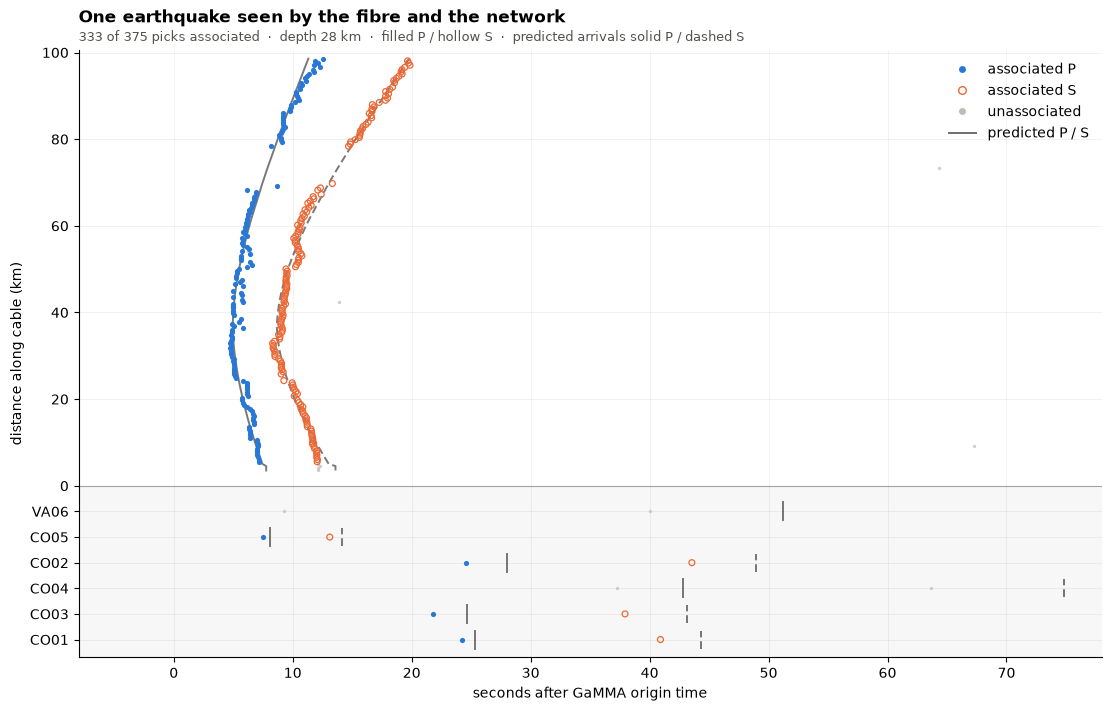

In [16]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- which picks GaMMA associated -----------------------------------------
# The land stations from the first run (they located the event on their own);
# the fibre from the combined one. A few hundred noisy channels give DBSCAN
# room to seed clusters that are not earthquakes, and it sometimes splits the
# main one in two -- both halves sit within a couple of seconds of the best
# origin, so take every event that close as the same quake.
origin = pd.Timestamp(best["time"])
lag = (pd.to_datetime(das_catalog["time"]) - origin).abs().dt.total_seconds()
quake = set(das_catalog.loc[lag < 5, "event_index"])

land_used = set(pd.DataFrame(assignments, columns=["pick", "event", "prob"])["pick"])
das_links = pd.DataFrame(das_assignments, columns=["pick", "event", "prob"])
das_used = set(das_links.loc[das_links["event"].isin(quake), "pick"])

n_land = len(gamma_picks)
p = combined_picks.assign(
    dt=(combined_picks["timestamp"] - origin).dt.total_seconds(),
    is_p=combined_picks["type"].str.upper().eq("P"),
    assoc=[i in land_used if i < n_land else i in das_used for i in combined_picks.index],
)

# --- a y position for every pick: km along the cable, or a lane per station -
geom = combined_stations.set_index("id")
is_das = geom.index.str.startswith("DAS.")
cable = pd.Series(
    geom.index[is_das].str.split(".").str[1].astype(float).to_numpy() / 1e3,
    index=geom.index[is_das],
)
land = geom[~is_das].sort_values("longitude")  # west to east
step = 0.06 * cable.max()
lane = {sid: -step * (k + 1) for k, sid in enumerate(land.index)}
p["y"] = p["id"].map(lambda s: lane.get(s, cable.get(s, np.nan)))

# --- arrivals predicted from the located hypocentre -----------------------
ex, ey, ez = best["x(km)"], best["y(km)"], best["depth(km)"]
hypo = np.sqrt(
    (geom["x(km)"] - ex) ** 2 + (geom["y(km)"] - ey) ** 2 + (geom["z(km)"] - ez) ** 2
)
tp, ts = hypo / config["vel"]["p"], hypo / config["vel"]["s"]
order = cable.sort_values().index

# --- draw ---------------------------------------------------------------
INK, GREY, P_C, S_C = "#0b0b0b", "#bdbcb6", "#2a78d6", "#eb6834"
fig, ax = plt.subplots(figsize=(11, 7), layout="constrained")
ax.axhspan(min(lane.values()) - step, 0, color=INK, alpha=0.03, zorder=0)

ax.plot(tp[order], cable[order], color=INK, lw=1.4, alpha=0.55, zorder=2)
ax.plot(ts[order], cable[order], color=INK, lw=1.4, alpha=0.55, ls=(0, (4, 2)), zorder=2)
for sid, y in lane.items():
    for t, dash in ((tp[sid], "-"), (ts[sid], (0, (4, 2)))):
        ax.plot([t, t], [y - 0.35 * step, y + 0.35 * step], color=INK, lw=1.4, alpha=0.55, ls=dash)

noise = p[~p["assoc"]]
ax.scatter(noise["dt"], noise["y"], s=6, c=GREY, lw=0, alpha=0.7, zorder=3)
hit = p[p["assoc"]]
ax.scatter(hit.loc[hit["is_p"], "dt"], hit.loc[hit["is_p"], "y"], s=14, c=P_C, lw=0, zorder=5)
ax.scatter(
    hit.loc[~hit["is_p"], "dt"], hit.loc[~hit["is_p"], "y"],
    s=18, facecolors="none", edgecolors=S_C, lw=0.9, zorder=5,
)

ax.axhline(0, color=INK, lw=0.8, alpha=0.3)
pos = [t for t in ax.get_yticks() if t >= 0]
ax.set_yticks(pos + list(lane.values()))
ax.set_yticklabels([f"{t:g}" for t in pos] + [s.split(".")[-1] for s in lane])
ax.set_xlim(-8, 78)
ax.set_ylim(min(lane.values()) - 0.7 * step, cable.max() * 1.02)
ax.set_xlabel("seconds after GaMMA origin time")
ax.set_ylabel("distance along cable (km)")
ax.grid(True, color=INK, alpha=0.06, lw=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title(
    "One earthquake seen by the fibre and the network",
    loc="left", pad=20, fontweight="bold",
)
ax.text(
    0, 1.015,
    f"{int(p['assoc'].sum())} of {len(p)} picks associated  ·  "
    f"depth {best['depth(km)']:.0f} km  ·  filled P / hollow S  ·  "
    "predicted arrivals solid P / dashed S",
    transform=ax.transAxes, fontsize=9, color="#52514e",
)
ax.legend(
    handles=[
        Line2D([], [], marker="o", ls="none", ms=5, mfc=P_C, mec="none", label="associated P"),
        Line2D([], [], marker="o", ls="none", ms=5.5, mfc="none", mec=S_C, mew=1, label="associated S"),
        Line2D([], [], marker="o", ls="none", ms=5, mfc=GREY, mec="none", label="unassociated"),
        Line2D([], [], color=INK, lw=1.4, alpha=0.6, label="predicted P / S"),
    ],
    loc="upper right", frameon=False,
)
plt.show()